# PCA — Weekend Gap Prediction

All PCA variants for the tabular feature space. Every variant is evaluated under **two orthogonal validation strategies**:

- **Year folds** — expanding calendar-year window (2019–2024), COVID fold (2020) excluded from averages.
- **TimeSeriesSplit(N)** — with **N cross-validated per model family** by sweeping `n_splits ∈ [6, 20]` and picking the value with the highest mean AUC for that family.

**Feature sets (match the canonical notebooks).**

| Model family | Feature count | Notes |
|---|---|---|
| LogReg variants | 18 | Drops RSI / GrossMargin / WeeklyRange (VIF > 10) |
| XGBoost variants | 21 | RSI + GrossMargin + WeeklyRange added back — collinearity doesn't hurt trees |

**Variants tested.**

| Variant | Model | PCA strategy | Hyperparameter selection |
|---|---|---|---|
| Baseline LogReg | LogReg L1 | none | C tuned per fold |
| Per-fold PCA + LogReg | LogReg L1 | fit per training fold | k swept, C tuned per fold at every k |
| Global PCA + LogReg | LogReg L1 | fit once on full data | k swept, C tuned per fold (upper bound) |
| Baseline XGBoost | XGBoost | none | 48-combo grid × n_estimators=500 + ES=30 |
| Per-fold PCA + XGBoost | XGBoost | fit per training fold | same 48-combo grid at k=best_k_year |

**Reporting.** Per variant: AUC-ROC, Accuracy, Precision/Recall/F1, confusion matrices, ROC curves, feature importance. Best variant by non-COVID year-fold AUC is pickled to `final_outputs/pca_results.pkl`.

In [7]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA

from _helpers.data import (load_dataset, TABULAR_FEATURES, XGBOOST_FEATURES, TARGET)
from _helpers.preprocessing import preprocess_tabular, global_preprocess_tabular
from _helpers.splits import (build_year_folds_tabular, build_tscv_folds,
                              TABULAR_FOLDS_DEF, non_covid_mean)
from _helpers.tabular_models import (run_logreg_year, run_logreg_tscv,
                                      pca_sweep_logreg, global_pca_sweep_logreg,
                                      pca_logreg_detail,
                                      run_xgb_year, run_xgb_tscv,
                                      sweep_tscv_n_splits_logreg,
                                      sweep_tscv_n_splits_xgb,
                                      XGB_PARAM_GRID)
from _helpers.plotting import (plot_roc_grid, plot_cm_grid,
                                plot_feature_importance, plot_tscv_distribution)
from _helpers.pickling import (save_results, build_result_payload,
                                summarize_variant, pick_best,
                                FINAL_OUTPUTS_DIR)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 1. Load data & define feature views

Two feature matrices from the same `primary` frame: 18 columns for LogReg / PCA-LogReg, 21 columns for XGBoost variants.

In [8]:
_, primary, extreme = load_dataset()

# LogReg feature view (18)
X_lr = primary[TABULAR_FEATURES].reset_index(drop=True)
# XGBoost feature view (21)
X_xgb = primary[XGBOOST_FEATURES].reset_index(drop=True)

y_all = primary[TARGET].reset_index(drop=True)
tickers_all = primary['Ticker'].reset_index(drop=True)
dates_all = primary['Date'].reset_index(drop=True)

year_folds, _ = build_year_folds_tabular(primary)
yr_test_years = [fd['test_year'] for fd in TABULAR_FOLDS_DEF]

print(f'Primary rows: {len(primary):,}   Extreme rows: {len(extreme):,}')
print(f'LogReg features: {len(TABULAR_FEATURES)}   XGBoost features: {len(XGBOOST_FEATURES)}')
print(f'Date range: {dates_all.min().date()} → {dates_all.max().date()}')

Primary rows: 8,146   Extreme rows: 291
LogReg features: 18   XGBoost features: 21
Date range: 2016-04-18 → 2024-12-23


## 2. Cross-validate `n_splits` — per model family

LogReg and XGBoost have different variance profiles across fold counts, so each family gets its own optimal `n_splits`. We sweep `n_splits ∈ [6, 20]` independently for each:

- **LogReg sweep** — full per-fold C tuning (same recipe as the final evaluation).
- **XGBoost sweep** — simple `lr=0.05 + ES=30` reference recipe (no 48-combo grid — too expensive to sweep 15 × 48 fits).

Each family then uses its own `best_n_splits` for every subsequent tscv evaluation.

-- LogReg n_splits sweep --
  [LogReg] n_splits= 6  AUC=0.5858 ± 0.0446  Acc=0.5655
  [LogReg] n_splits= 7  AUC=0.5698 ± 0.0214  Acc=0.5435
  [LogReg] n_splits= 8  AUC=0.5899 ± 0.0551  Acc=0.5605
  [LogReg] n_splits= 9  AUC=0.5776 ± 0.0512  Acc=0.5557
  [LogReg] n_splits=10  AUC=0.5749 ± 0.0283  Acc=0.5561
  [LogReg] n_splits=11  AUC=0.5844 ± 0.0370  Acc=0.5610
  [LogReg] n_splits=12  AUC=0.5847 ± 0.0512  Acc=0.5668
  [LogReg] n_splits=13  AUC=0.5857 ± 0.0593  Acc=0.5698
  [LogReg] n_splits=14  AUC=0.5835 ± 0.0515  Acc=0.5647
  [LogReg] n_splits=15  AUC=0.5808 ± 0.0580  Acc=0.5580
  [LogReg] n_splits=16  AUC=0.5827 ± 0.0521  Acc=0.5605
  [LogReg] n_splits=17  AUC=0.5818 ± 0.0559  Acc=0.5586
  [LogReg] n_splits=18  AUC=0.5784 ± 0.0575  Acc=0.5636
  [LogReg] n_splits=19  AUC=0.5801 ± 0.0590  Acc=0.5612
  [LogReg] n_splits=20  AUC=0.5810 ± 0.0641  Acc=0.5625

-- XGBoost n_splits sweep --
  [XGBoost] n_splits= 6  AUC=0.5517 ± 0.0212  Acc=0.5324
  [XGBoost] n_splits= 7  AUC=0.5624 ± 0.0217 

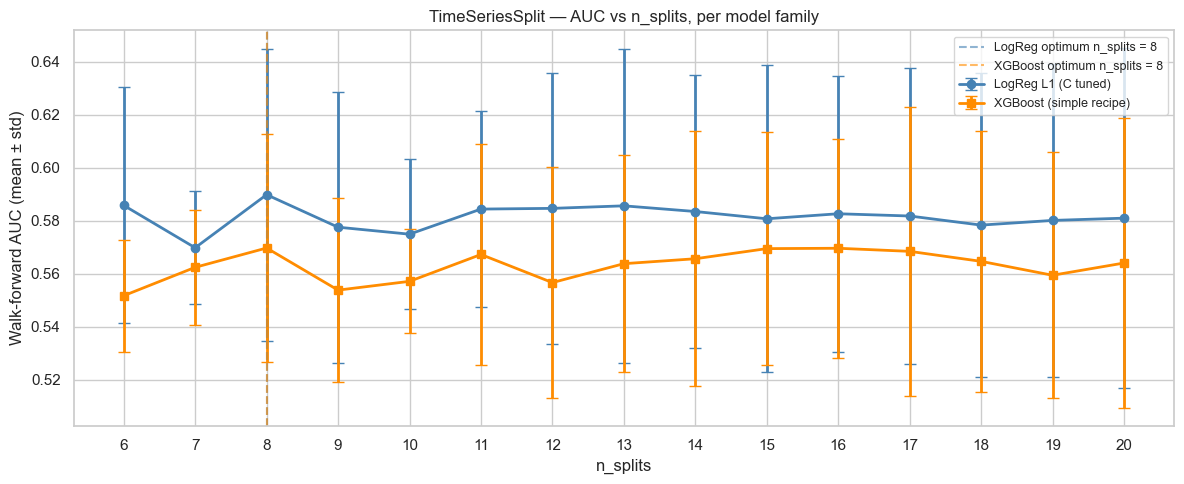


LogReg  variants → tscv(8)
XGBoost variants → tscv(8)


In [9]:
print('-- LogReg n_splits sweep --')
wf_lr, best_n_splits_lr = sweep_tscv_n_splits_logreg(
    X_lr, y_all, tickers_all, TABULAR_FEATURES,
    n_splits_range=range(6, 21))

print(f'\n-- XGBoost n_splits sweep --')
wf_xgb, best_n_splits_xgb = sweep_tscv_n_splits_xgb(
    X_xgb, y_all, tickers_all, XGBOOST_FEATURES,
    n_splits_range=range(6, 21))

best_lr_row  = wf_lr [wf_lr ['n_splits'] == best_n_splits_lr ].iloc[0]
best_xgb_row = wf_xgb[wf_xgb['n_splits'] == best_n_splits_xgb].iloc[0]
print(f'\nLogReg  best n_splits = {best_n_splits_lr:2d}   '
      f'AUC = {best_lr_row["auc_mean"]:.4f} ± {best_lr_row["auc_std"]:.4f}')
print(f'XGBoost best n_splits = {best_n_splits_xgb:2d}   '
      f'AUC = {best_xgb_row["auc_mean"]:.4f} ± {best_xgb_row["auc_std"]:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(wf_lr ['n_splits'], wf_lr ['auc_mean'], yerr=wf_lr ['auc_std'],
            fmt='o-', color='steelblue', lw=2, capsize=4, label='LogReg L1 (C tuned)')
ax.errorbar(wf_xgb['n_splits'], wf_xgb['auc_mean'], yerr=wf_xgb['auc_std'],
            fmt='s-', color='darkorange', lw=2, capsize=4, label='XGBoost (simple recipe)')
ax.axvline(best_n_splits_lr,  color='steelblue',  ls='--', alpha=0.6,
           label=f'LogReg optimum n_splits = {best_n_splits_lr}')
ax.axvline(best_n_splits_xgb, color='darkorange', ls='--', alpha=0.6,
           label=f'XGBoost optimum n_splits = {best_n_splits_xgb}')
ax.set(xlabel='n_splits', ylabel='Walk-forward AUC (mean ± std)',
       title='TimeSeriesSplit — AUC vs n_splits, per model family')
ax.set_xticks(list(range(6, 21)))
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

tscv_folds_lr,  _ = build_tscv_folds(X_lr,  n_splits=best_n_splits_lr)
tscv_folds_xgb, _ = build_tscv_folds(X_xgb, n_splits=best_n_splits_xgb)
print(f'\nLogReg  variants → tscv({best_n_splits_lr})')
print(f'XGBoost variants → tscv({best_n_splits_xgb})')

## 3. Baseline — LogReg L1, no PCA

C tuned per fold (last training year for year folds; last 20 % of train for tscv folds).

In [10]:
lr_year = run_logreg_year(primary, X_lr, y_all, tickers_all,
                           TABULAR_FEATURES, TABULAR_FOLDS_DEF)
lr_tscv = run_logreg_tscv(X_lr, y_all, tickers_all,
                           TABULAR_FEATURES, tscv_folds_lr)

bl_auc_year = non_covid_mean(lr_year['aucs'], lr_year['test_years'])
bl_acc_year = non_covid_mean(lr_year['accs'], lr_year['test_years'])
bl_auc_tscv = float(np.mean(lr_tscv['aucs']))
bl_acc_tscv = float(np.mean(lr_tscv['accs']))

print(f'Baseline LogReg — year folds            : AUC={bl_auc_year:.4f}  Acc={bl_acc_year:.4f}')
print(f'  year-fold best Cs: {lr_year["best_cs"]}')
print(f'Baseline LogReg — tscv({best_n_splits_lr:2d})              : AUC={bl_auc_tscv:.4f}  Acc={bl_acc_tscv:.4f}')
print(f'  tscv best Cs:      {lr_tscv["best_cs"]}')

Baseline LogReg — year folds            : AUC=0.5736  Acc=0.5523
  year-fold best Cs: [0.01, 0.005, 0.05, 0.005, 0.05, 0.05]
Baseline LogReg — tscv( 8)              : AUC=0.5899  Acc=0.5605
  tscv best Cs:      [0.05, 0.01, 0.01, 0.01, 0.05, 0.005, 0.05, 0.005]


## 4. Explained variance analysis

Fitted on the last year-based training fold (2016–2023) for visualisation. Minimum k retaining 90 % / 95 % of total variance.

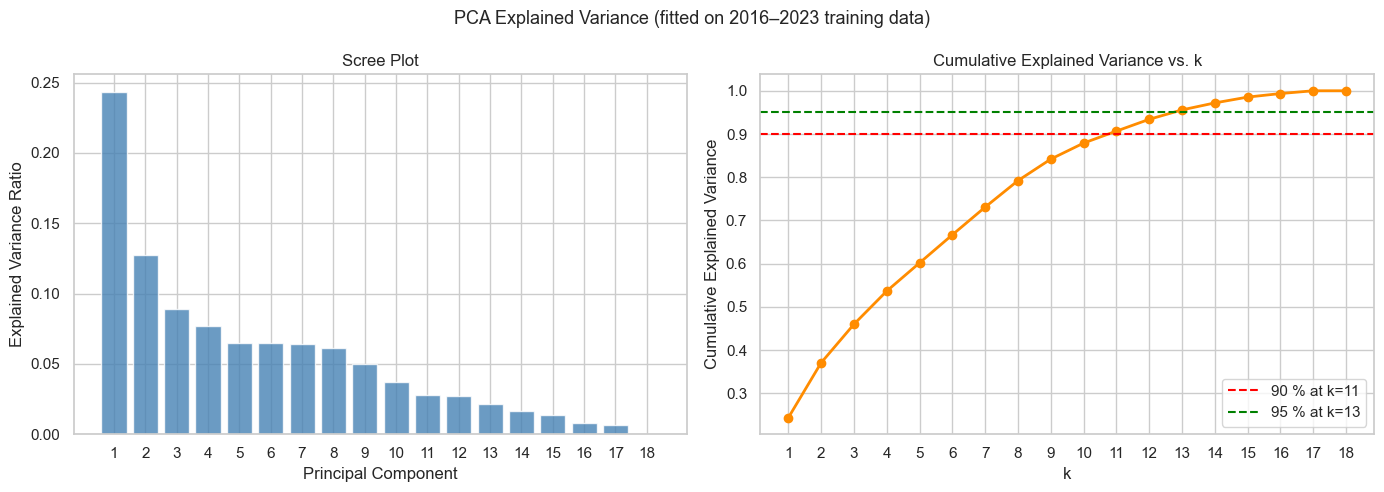

90 % at k=11   95 % at k=13


In [11]:
last_tr_yr, last_te_yr = year_folds[-1]
X_vis_tr, _ = preprocess_tabular(
    X_lr.iloc[last_tr_yr], X_lr.iloc[last_te_yr],
    tickers_all.iloc[last_tr_yr], tickers_all.iloc[last_te_yr],
    TABULAR_FEATURES)

pca_full = PCA(n_components=len(TABULAR_FEATURES)).fit(X_vis_tr)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumvar >= 0.90) + 1)
n_95 = int(np.argmax(cumvar >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(TABULAR_FEATURES) + 1),
            pca_full.explained_variance_ratio_,
            color='steelblue', alpha=0.8)
axes[0].set(xlabel='Principal Component', ylabel='Explained Variance Ratio',
            title='Scree Plot')
axes[0].set_xticks(range(1, len(TABULAR_FEATURES) + 1))
axes[1].plot(range(1, len(TABULAR_FEATURES) + 1), cumvar, 'o-',
             color='darkorange', lw=2)
axes[1].axhline(0.90, color='red', ls='--', label=f'90 % at k={n_90}')
axes[1].axhline(0.95, color='green', ls='--', label=f'95 % at k={n_95}')
axes[1].set(xlabel='k', ylabel='Cumulative Explained Variance',
            title='Cumulative Explained Variance vs. k')
axes[1].set_xticks(range(1, len(TABULAR_FEATURES) + 1))
axes[1].legend()
plt.suptitle('PCA Explained Variance (fitted on 2016–2023 training data)',
             fontsize=13)
plt.tight_layout(); plt.show()
print(f'90 % at k={n_90}   95 % at k={n_95}')

## 5. Per-fold PCA sweep (no leakage) — C tuned per fold at every k

PCA fitted on each training fold only. For each (k, fold) we additionally tune C on the inner-val set **after** PCA projection. LogReg tscv uses `tscv(best_n_splits_lr)`.

In [12]:
ks = list(range(1, len(TABULAR_FEATURES) + 1))

print('--- Year folds ---')
pca_year_sweep, best_k_year = pca_sweep_logreg(
    year_folds, X_lr, y_all, tickers_all, TABULAR_FEATURES,
    ks, primary=primary, folds_def=TABULAR_FOLDS_DEF,
    test_years=yr_test_years, label='year')

print(f'\n--- TimeSeriesSplit({best_n_splits_lr}) ---')
pca_tscv_sweep, best_k_tscv = pca_sweep_logreg(
    tscv_folds_lr, X_lr, y_all, tickers_all, TABULAR_FEATURES,
    ks, label='tscv')

print(f'\nBest k — year folds: {best_k_year}   tscv({best_n_splits_lr}): {best_k_tscv}')
print(f'Per-fold Cs at best k (year): {pca_year_sweep[best_k_year]["best_cs"]}')

--- Year folds ---
  [year] k= 1 | acc=0.5475  auc=0.5564
  [year] k= 2 | acc=0.5433  auc=0.5553
  [year] k= 3 | acc=0.5418  auc=0.5616
  [year] k= 4 | acc=0.5469  auc=0.5579
  [year] k= 5 | acc=0.5471  auc=0.5564
  [year] k= 6 | acc=0.5440  auc=0.5559
  [year] k= 7 | acc=0.5439  auc=0.5529
  [year] k= 8 | acc=0.5398  auc=0.5518
  [year] k= 9 | acc=0.5412  auc=0.5516
  [year] k=10 | acc=0.5409  auc=0.5519
  [year] k=11 | acc=0.5405  auc=0.5543
  [year] k=12 | acc=0.5431  auc=0.5546
  [year] k=13 | acc=0.5441  auc=0.5614
  [year] k=14 | acc=0.5439  auc=0.5614
  [year] k=15 | acc=0.5475  auc=0.5616
  [year] k=16 | acc=0.5473  auc=0.5615
  [year] k=17 | acc=0.5463  auc=0.5604
  [year] k=18 | acc=0.5463  auc=0.5604

--- TimeSeriesSplit(8) ---
  [tscv] k= 1 | acc=0.5354  auc=0.5601
  [tscv] k= 2 | acc=0.5343  auc=0.5557
  [tscv] k= 3 | acc=0.5247  auc=0.5677
  [tscv] k= 4 | acc=0.5298  auc=0.5677
  [tscv] k= 5 | acc=0.5380  auc=0.5675
  [tscv] k= 6 | acc=0.5401  auc=0.5662
  [tscv] k= 7 | a

## 6. Global PCA sweep (upper bound) — C tuned per fold

PCA fitted once on the full preprocessed dataset. Upper bound — if global PCA doesn't beat per-fold PCA, leakage is not the bottleneck.

In [13]:
X_all_preprocessed = global_preprocess_tabular(X_lr, tickers_all, TABULAR_FEATURES)

print('--- Year folds ---')
gpca_year_sweep, best_kg_year = global_pca_sweep_logreg(
    year_folds, X_all_preprocessed, y_all, ks,
    primary=primary, folds_def=TABULAR_FOLDS_DEF,
    test_years=yr_test_years, label='year')

print(f'\n--- TimeSeriesSplit({best_n_splits_lr}) ---')
gpca_tscv_sweep, best_kg_tscv = global_pca_sweep_logreg(
    tscv_folds_lr, X_all_preprocessed, y_all, ks, label='tscv')

--- Year folds ---
  [year] k= 1 | acc=0.5470  auc=0.5598
  [year] k= 2 | acc=0.5490  auc=0.5602
  [year] k= 3 | acc=0.5367  auc=0.5585
  [year] k= 4 | acc=0.5444  auc=0.5581
  [year] k= 5 | acc=0.5446  auc=0.5580
  [year] k= 6 | acc=0.5437  auc=0.5569
  [year] k= 7 | acc=0.5443  auc=0.5564
  [year] k= 8 | acc=0.5402  auc=0.5514
  [year] k= 9 | acc=0.5396  auc=0.5510
  [year] k=10 | acc=0.5396  auc=0.5518
  [year] k=11 | acc=0.5407  auc=0.5525
  [year] k=12 | acc=0.5420  auc=0.5532
  [year] k=13 | acc=0.5440  auc=0.5593
  [year] k=14 | acc=0.5427  auc=0.5591
  [year] k=15 | acc=0.5454  auc=0.5597
  [year] k=16 | acc=0.5467  auc=0.5594
  [year] k=17 | acc=0.5444  auc=0.5582
  [year] k=18 | acc=0.5444  auc=0.5582

--- TimeSeriesSplit(8) ---
  [tscv] k= 1 | acc=0.5488  auc=0.5703
  [tscv] k= 2 | acc=0.5459  auc=0.5695
  [tscv] k= 3 | acc=0.5330  auc=0.5711
  [tscv] k= 4 | acc=0.5512  auc=0.5757
  [tscv] k= 5 | acc=0.5528  auc=0.5741
  [tscv] k= 6 | acc=0.5517  auc=0.5737
  [tscv] k= 7 | a

## 7. Sweep comparison chart

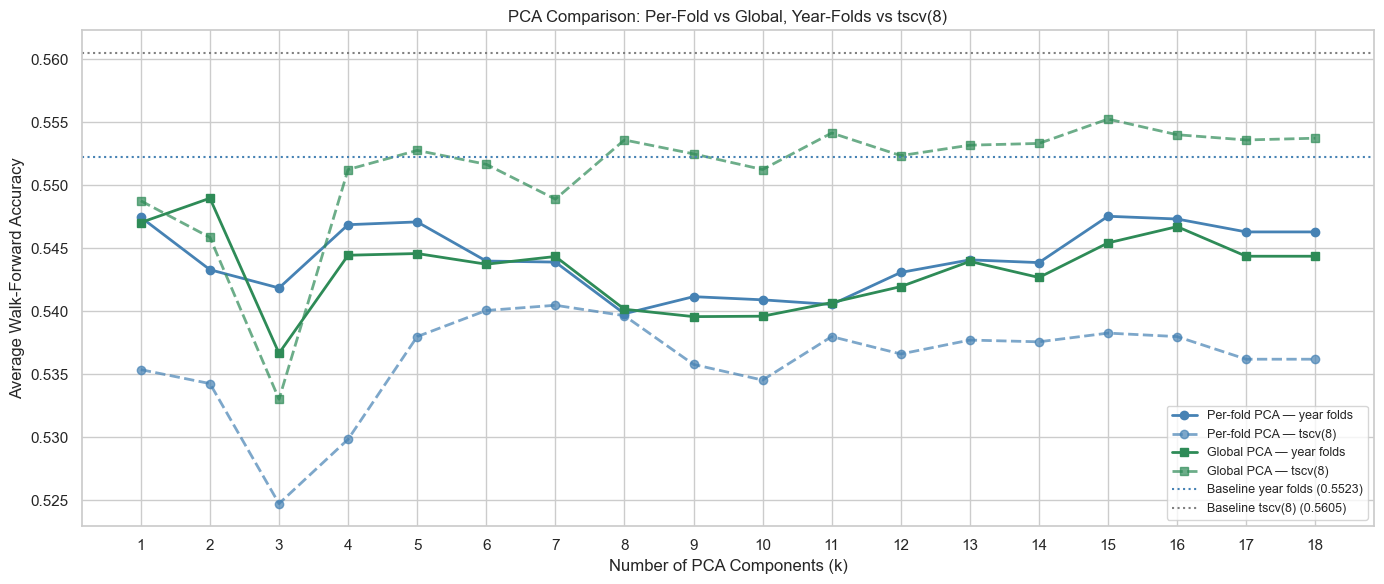

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ks, [pca_year_sweep[k]['avg_acc']  for k in ks], 'o-',  color='steelblue', lw=2, label='Per-fold PCA — year folds')
ax.plot(ks, [pca_tscv_sweep[k]['avg_acc']  for k in ks], 'o--', color='steelblue', lw=2, alpha=0.7, label=f'Per-fold PCA — tscv({best_n_splits_lr})')
ax.plot(ks, [gpca_year_sweep[k]['avg_acc'] for k in ks], 's-',  color='seagreen',  lw=2, label='Global PCA — year folds')
ax.plot(ks, [gpca_tscv_sweep[k]['avg_acc'] for k in ks], 's--', color='seagreen',  lw=2, alpha=0.7, label=f'Global PCA — tscv({best_n_splits_lr})')
ax.axhline(bl_acc_year, color='steelblue', ls=':', lw=1.5, label=f'Baseline year folds ({bl_acc_year:.4f})')
ax.axhline(bl_acc_tscv, color='grey',      ls=':', lw=1.5, label=f'Baseline tscv({best_n_splits_lr}) ({bl_acc_tscv:.4f})')
ax.set(xlabel='Number of PCA Components (k)',
       ylabel='Average Walk-Forward Accuracy',
       title=f'PCA Comparison: Per-Fold vs Global, Year-Folds vs tscv({best_n_splits_lr})')
ax.set_xticks(ks)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 8. 2D projection visualisation

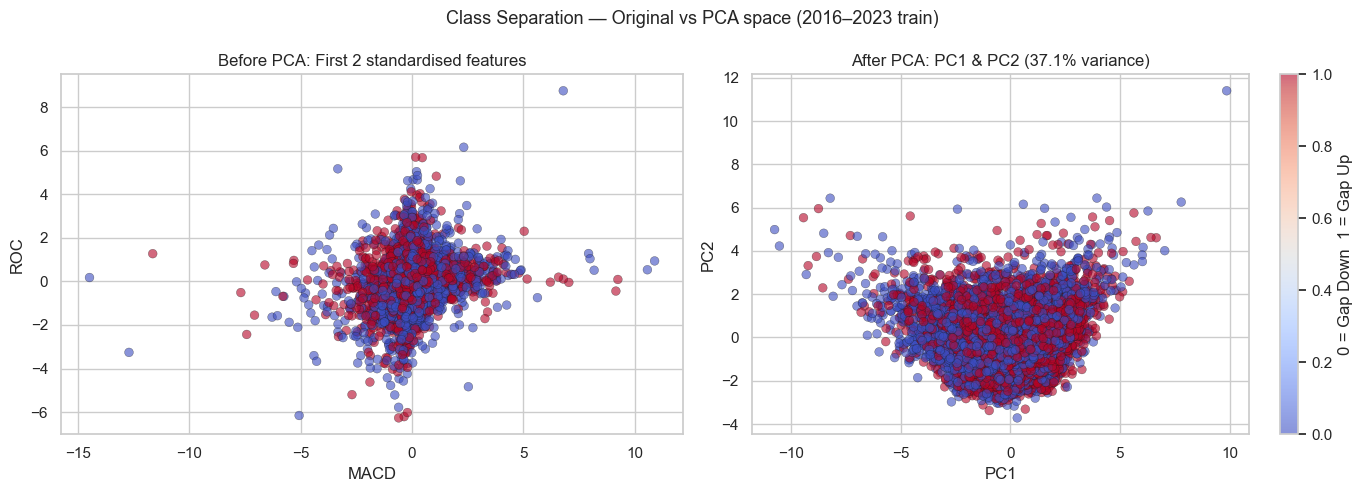

In [15]:
X_vis_2d = PCA(n_components=2).fit_transform(X_vis_tr)
y_vis = y_all.iloc[last_tr_yr].values
kw = dict(cmap='coolwarm', edgecolor='k', s=40, alpha=0.6, linewidths=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_vis_tr[:, 0], X_vis_tr[:, 1], c=y_vis, **kw)
axes[0].set(xlabel=TABULAR_FEATURES[0], ylabel=TABULAR_FEATURES[1],
            title='Before PCA: First 2 standardised features')
sc = axes[1].scatter(X_vis_2d[:, 0], X_vis_2d[:, 1], c=y_vis, **kw)
var_2 = pca_full.explained_variance_ratio_[:2].sum()
axes[1].set(xlabel='PC1', ylabel='PC2',
            title=f'After PCA: PC1 & PC2 ({var_2:.1%} variance)')
plt.colorbar(sc, ax=axes[1], label='0 = Gap Down  1 = Gap Up')
plt.suptitle('Class Separation — Original vs PCA space (2016–2023 train)', fontsize=13)
plt.tight_layout(); plt.show()

## 9. Per-fold PCA + LogReg — full detail at best k (year folds)

Refit at year-fold-optimal k with per-fold C tuning. Captures confusion matrices, ROC curves, and `|coef · loading|` feature importance.

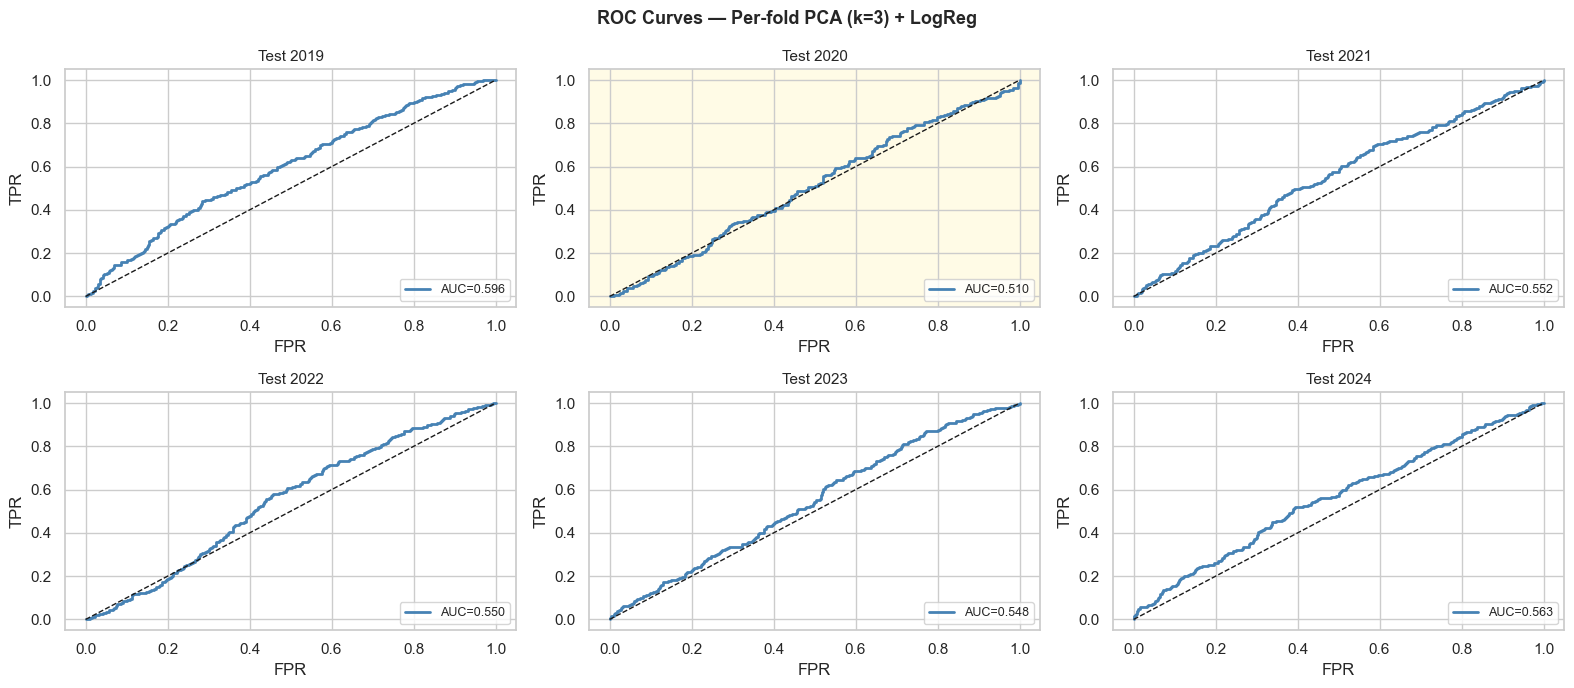

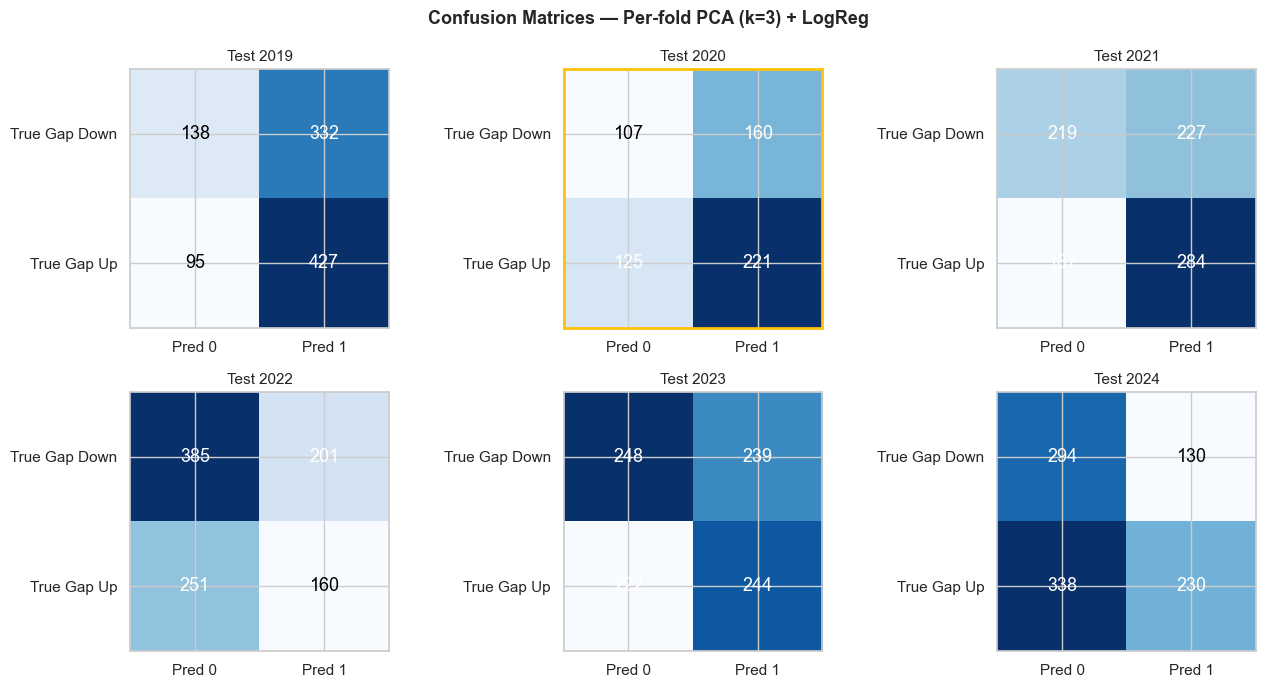

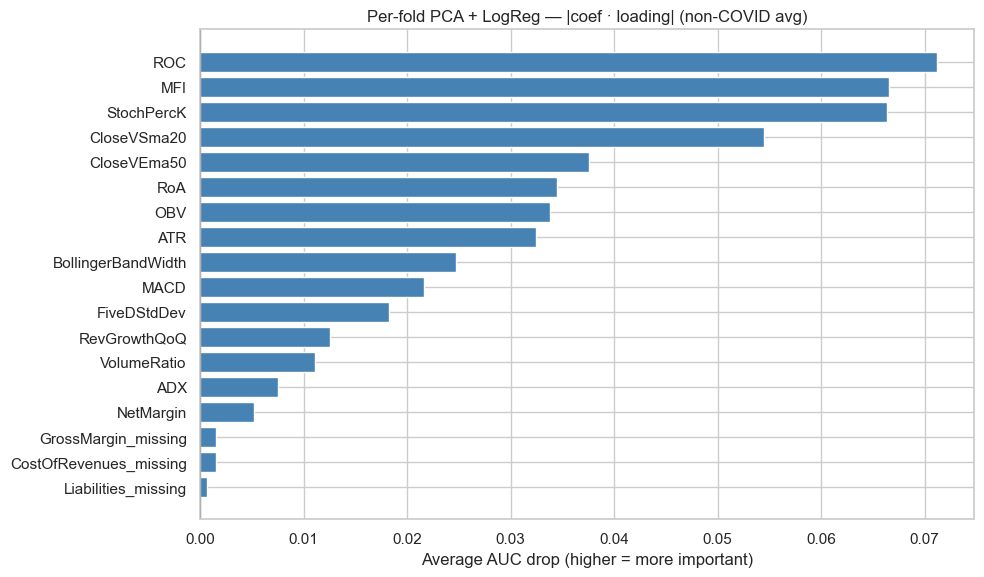

Per-fold Cs at best k: [0.05, 0.005, 0.5, 0.005, 5.0, 1.0]


In [16]:
pca_lr_detail_year = pca_logreg_detail(
    year_folds, X_lr, y_all, tickers_all, TABULAR_FEATURES,
    best_k_year, primary=primary, folds_def=TABULAR_FOLDS_DEF)

titles = pca_lr_detail_year['test_years']
plot_roc_grid(pca_lr_detail_year['rocs'], pca_lr_detail_year['aucs'],
              titles,
              suptitle=f'ROC Curves — Per-fold PCA (k={best_k_year}) + LogReg',
              covid_year=2020)
plot_cm_grid(pca_lr_detail_year['cms'], titles,
             suptitle=f'Confusion Matrices — Per-fold PCA (k={best_k_year}) + LogReg',
             covid_year=2020)

nc_idx = [i for i, yr in enumerate(titles) if yr != 2020]
avg_imp = (pd.DataFrame([pca_lr_detail_year['feature_importances'][i] for i in nc_idx])
             .mean().sort_values(ascending=False))
plot_feature_importance(pd.DataFrame({'Avg AUC drop': avg_imp}),
                        title='Per-fold PCA + LogReg — |coef · loading| (non-COVID avg)')
print(f'Per-fold Cs at best k: {pca_lr_detail_year["best_cs"]}')

## 10. XGBoost (21 features) — 48-combo grid × early stopping

48-combo grid (`max_depth × learning_rate × subsample × colsample_bytree × min_child_weight`). Each combo uses `n_estimators=500 + ES=30` on the inner-val set. XGBoost tscv uses `tscv(best_n_splits_xgb)`.

In [17]:
print('-- XGBoost (no PCA) — year folds --')
xgb_plain_year = run_xgb_year(primary, X_xgb, y_all, tickers_all,
                               XGBOOST_FEATURES, TABULAR_FOLDS_DEF,
                               use_pca=False)
print(f'-- XGBoost + PCA (k={best_k_year}) — year folds --')
xgb_pca_year   = run_xgb_year(primary, X_xgb, y_all, tickers_all,
                               XGBOOST_FEATURES, TABULAR_FOLDS_DEF,
                               use_pca=True, k=best_k_year)

print(f'-- XGBoost (no PCA) — tscv({best_n_splits_xgb}) --')
xgb_plain_tscv = run_xgb_tscv(X_xgb, y_all, tickers_all, XGBOOST_FEATURES,
                               tscv_folds_xgb, use_pca=False)
print(f'-- XGBoost + PCA (k={best_k_year}) — tscv({best_n_splits_xgb}) --')
xgb_pca_tscv   = run_xgb_tscv(X_xgb, y_all, tickers_all, XGBOOST_FEATURES,
                               tscv_folds_xgb, use_pca=True, k=best_k_year)

for lbl, res in [('XGBoost (no PCA)', xgb_plain_year),
                 (f'XGBoost + PCA (k={best_k_year})', xgb_pca_year)]:
    auc = non_covid_mean(res['aucs'], res['test_years'])
    acc = non_covid_mean(res['accs'], res['test_years'])
    print(f'{lbl:<35s}  year folds (nc)  Acc={acc:.4f}  AUC={auc:.4f}')

print(f'\nXGBoost (no PCA)                   '
      f'tscv({best_n_splits_xgb:2d})  Acc={np.mean(xgb_plain_tscv["accs"]):.4f}  AUC={np.mean(xgb_plain_tscv["aucs"]):.4f}')
print(f'XGBoost + PCA (k={best_k_year})                     '
      f'tscv({best_n_splits_xgb:2d})  Acc={np.mean(xgb_pca_tscv["accs"]):.4f}  AUC={np.mean(xgb_pca_tscv["aucs"]):.4f}')

-- XGBoost (no PCA) — year folds --
-- XGBoost + PCA (k=3) — year folds --
-- XGBoost (no PCA) — tscv(8) --
-- XGBoost + PCA (k=3) — tscv(8) --
XGBoost (no PCA)                     year folds (nc)  Acc=0.5475  AUC=0.5651
XGBoost + PCA (k=3)                  year folds (nc)  Acc=0.5330  AUC=0.5372

XGBoost (no PCA)                   tscv( 8)  Acc=0.5370  AUC=0.5729
XGBoost + PCA (k=3)                     tscv( 8)  Acc=0.5189  AUC=0.5621


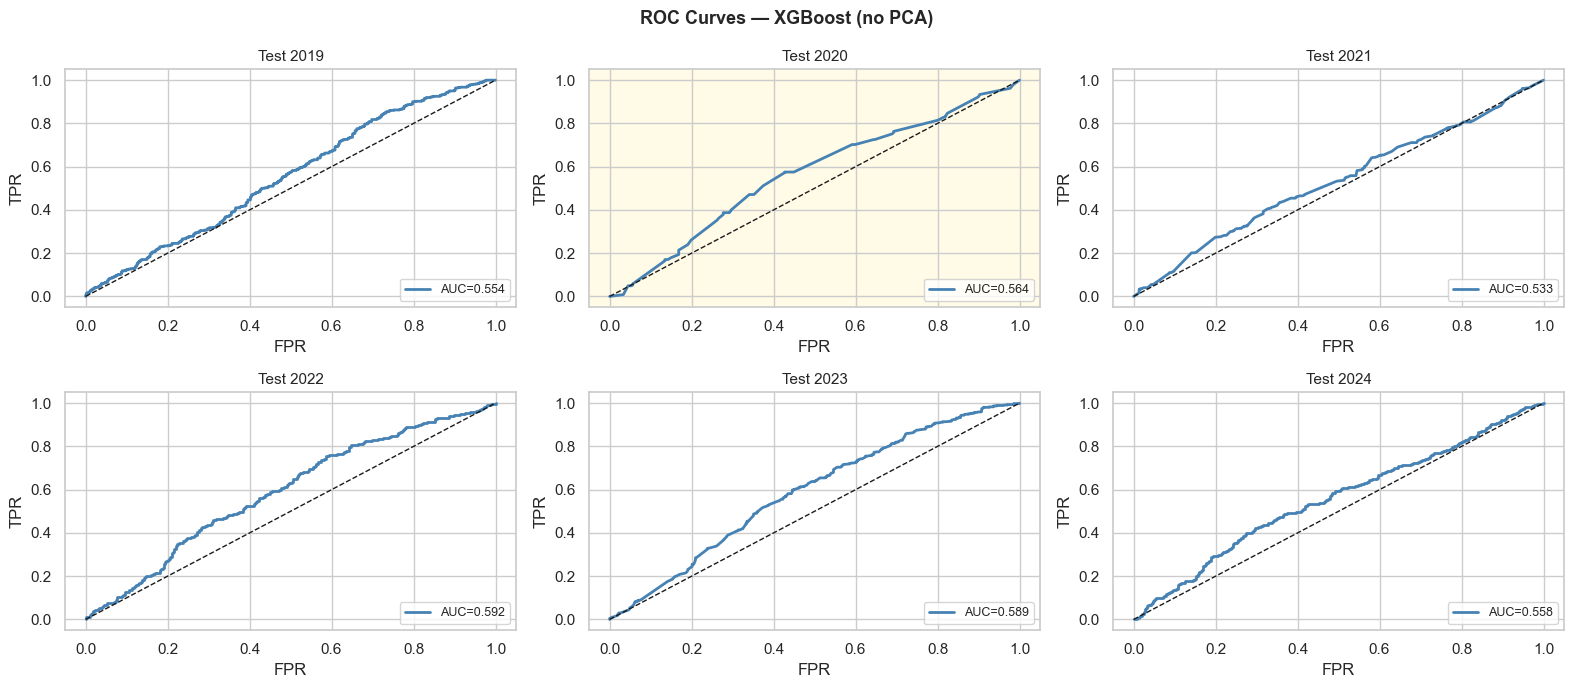

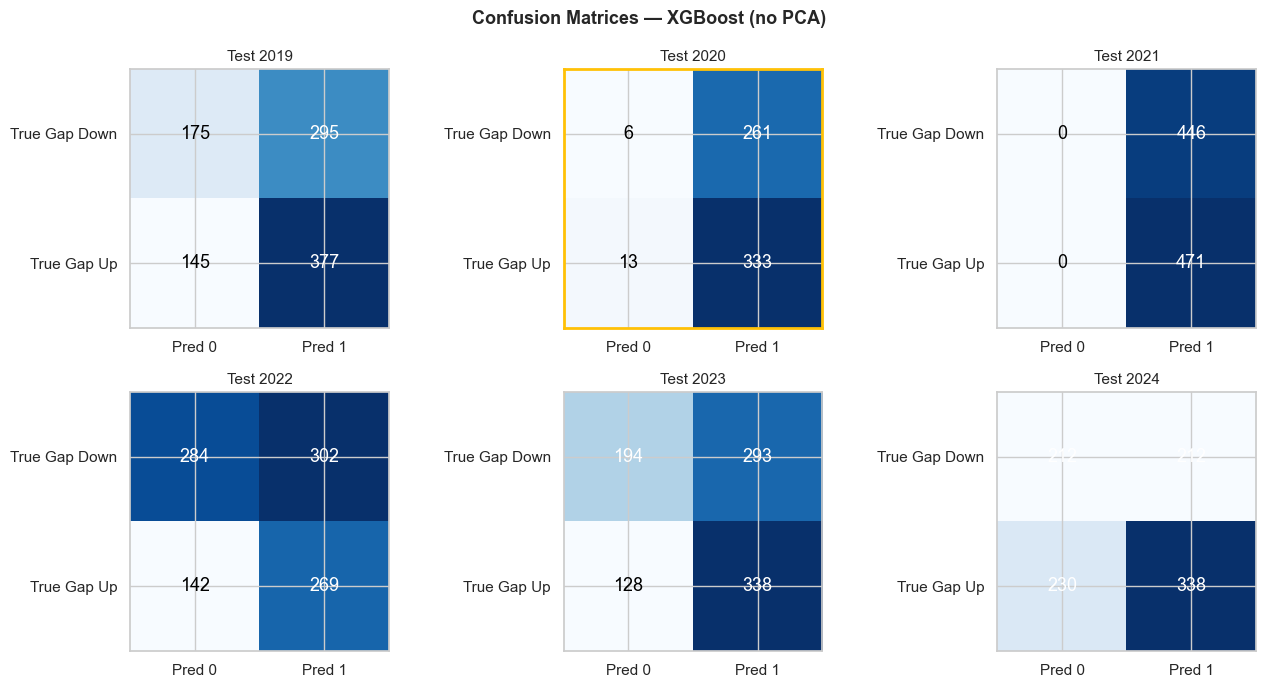

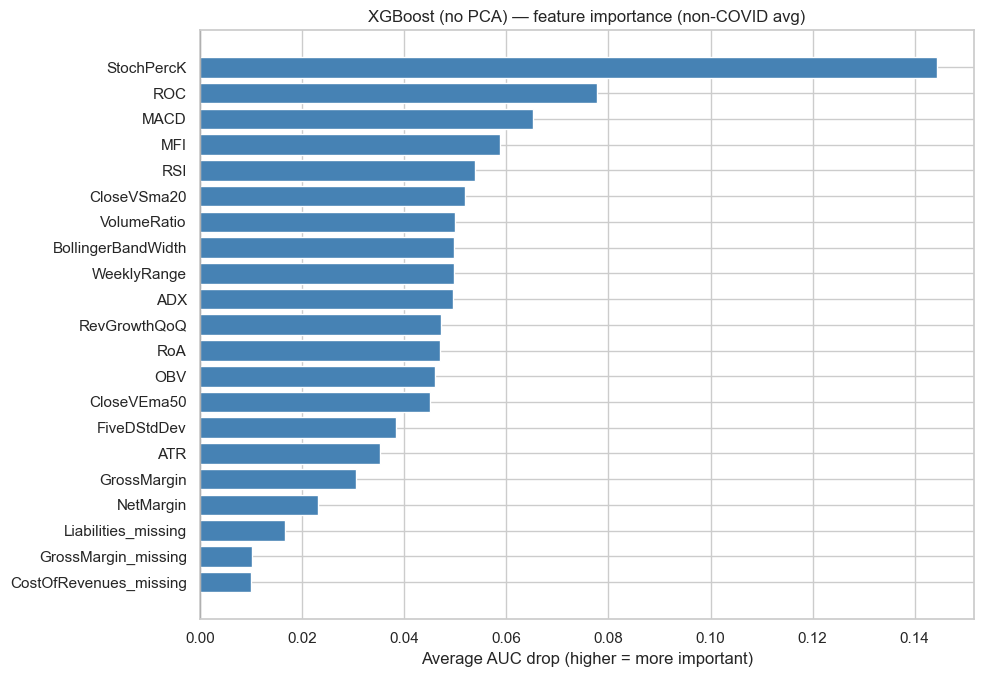

Best hyperparameters per fold:
  2019: {'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.9, 'min_child_weight': 3, 'n_estimators': 31}
  2020: {'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 1, 'n_estimators': 3}
  2021: {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'n_estimators': 2}
  2022: {'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'n_estimators': 23}
  2023: {'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'n_estimators': 4}
  2024: {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 3, 'n_estimators': 116}


In [18]:
xgb_best_year = (xgb_pca_year
                 if non_covid_mean(xgb_pca_year['aucs'], xgb_pca_year['test_years']) >
                    non_covid_mean(xgb_plain_year['aucs'], xgb_plain_year['test_years'])
                 else xgb_plain_year)
xgb_best_label = ('XGBoost + PCA' if xgb_best_year is xgb_pca_year
                  else 'XGBoost (no PCA)')

plot_roc_grid(xgb_best_year['rocs'], xgb_best_year['aucs'],
              xgb_best_year['test_years'],
              suptitle=f'ROC Curves — {xgb_best_label}',
              covid_year=2020)
plot_cm_grid(xgb_best_year['cms'], xgb_best_year['test_years'],
             suptitle=f'Confusion Matrices — {xgb_best_label}',
             covid_year=2020)

nc = [i for i, yr in enumerate(xgb_best_year['test_years']) if yr != 2020]
avg_imp_xgb = (pd.DataFrame([xgb_best_year['feature_importances'][i] for i in nc])
                 .mean().sort_values(ascending=False))
plot_feature_importance(pd.DataFrame({'Avg AUC drop': avg_imp_xgb}),
                        title=f'{xgb_best_label} — feature importance (non-COVID avg)')

print('Best hyperparameters per fold:')
for yr, p in zip(xgb_best_year['test_years'], xgb_best_year['best_params']):
    print(f'  {yr}: {p}')

## 11. tscv distribution — LogReg L1 vs XGBoost

Per-fold AUC / Accuracy distribution. Note the two series are drawn from **different** fold counts (`tscv(best_n_splits_lr)` vs `tscv(best_n_splits_xgb)`) — so they share an axis, not a fold count.

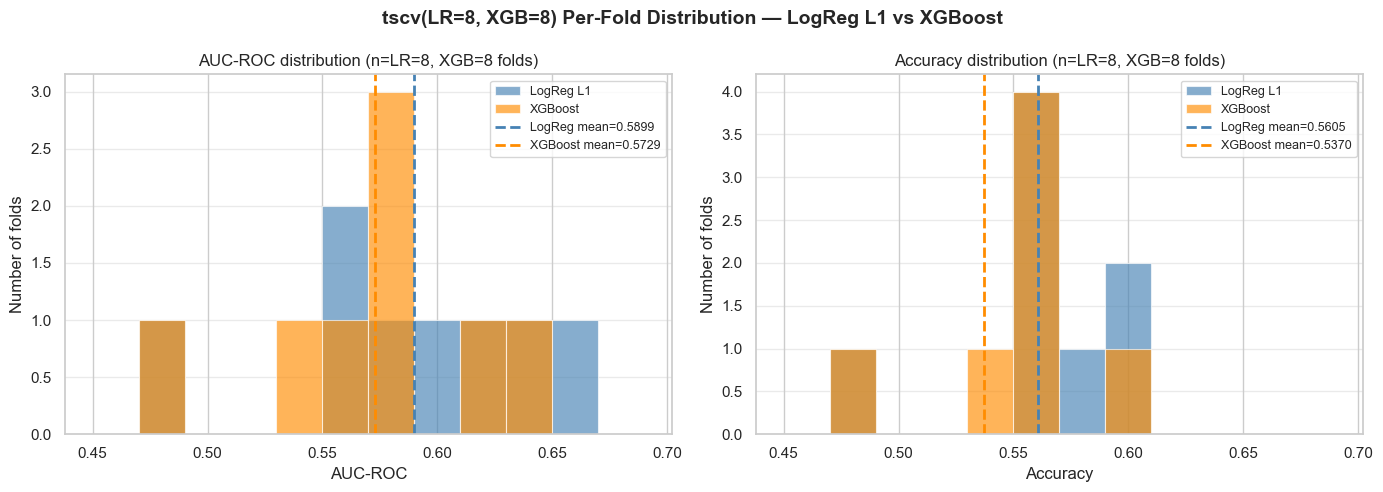

In [19]:
plot_tscv_distribution(lr_tscv['aucs'], xgb_plain_tscv['aucs'],
                        lr_tscv['accs'], xgb_plain_tscv['accs'],
                        n_folds=f'LR={best_n_splits_lr}, XGB={best_n_splits_xgb}')

## 12. Variant summary & best-model selection

Best = highest **non-COVID year-fold AUC**. Full artifacts of that variant are pickled to `final_outputs/pca_results.pkl`.

In [20]:
all_variants = {}

all_variants['LogReg baseline'] = summarize_variant(
    'LogReg baseline',
    yearly_aucs=lr_year['aucs'], yearly_accs=lr_year['accs'],
    yearly_test_years=lr_year['test_years'],
    tscv_aucs=lr_tscv['aucs'], tscv_accs=lr_tscv['accs'],
    n_features=len(TABULAR_FEATURES),
    extra={'tscv_n_splits': best_n_splits_lr})

all_variants[f'Per-fold PCA + LogReg (k={best_k_year})'] = summarize_variant(
    f'Per-fold PCA + LogReg (k={best_k_year})',
    yearly_aucs=pca_lr_detail_year['aucs'],
    yearly_accs=pca_lr_detail_year['accs'],
    yearly_test_years=pca_lr_detail_year['test_years'],
    tscv_aucs=pca_tscv_sweep[best_k_tscv]['fold_aucs'],
    tscv_accs=pca_tscv_sweep[best_k_tscv]['fold_accs'],
    n_features=best_k_year,
    extra={'k_year': best_k_year, 'k_tscv': best_k_tscv,
           'best_cs_year': pca_lr_detail_year['best_cs'],
           'tscv_n_splits': best_n_splits_lr})

all_variants[f'Global PCA + LogReg (k={best_kg_year})'] = summarize_variant(
    f'Global PCA + LogReg (k={best_kg_year})',
    yearly_aucs=gpca_year_sweep[best_kg_year]['fold_aucs'],
    yearly_accs=gpca_year_sweep[best_kg_year]['fold_accs'],
    yearly_test_years=yr_test_years,
    tscv_aucs=gpca_tscv_sweep[best_kg_tscv]['fold_aucs'],
    tscv_accs=gpca_tscv_sweep[best_kg_tscv]['fold_accs'],
    n_features=best_kg_year,
    extra={'k_year': best_kg_year, 'k_tscv': best_kg_tscv,
           'note': 'global PCA = upper bound (mild leakage)',
           'tscv_n_splits': best_n_splits_lr})

all_variants['XGBoost baseline'] = summarize_variant(
    'XGBoost baseline',
    yearly_aucs=xgb_plain_year['aucs'], yearly_accs=xgb_plain_year['accs'],
    yearly_test_years=xgb_plain_year['test_years'],
    tscv_aucs=xgb_plain_tscv['aucs'], tscv_accs=xgb_plain_tscv['accs'],
    n_features=len(XGBOOST_FEATURES),
    extra={'tscv_n_splits': best_n_splits_xgb})

all_variants[f'XGBoost + PCA (k={best_k_year})'] = summarize_variant(
    f'XGBoost + PCA (k={best_k_year})',
    yearly_aucs=xgb_pca_year['aucs'], yearly_accs=xgb_pca_year['accs'],
    yearly_test_years=xgb_pca_year['test_years'],
    tscv_aucs=xgb_pca_tscv['aucs'], tscv_accs=xgb_pca_tscv['accs'],
    n_features=best_k_year,
    extra={'tscv_n_splits': best_n_splits_xgb})

rows = []
for name, v in all_variants.items():
    rows.append({
        'Variant': name, 'Feats': v['n_features'],
        'tscv_N': v.get('tscv_n_splits'),
        'Yearly AUC (nc)': round(v['yearly_auc_nc'], 4),
        'Yearly Acc (nc)': round(v['yearly_acc_nc'], 4),
        'tscv AUC': round(v['tscv_auc'], 4) if v['tscv_auc'] else None,
        'tscv Acc': round(v['tscv_acc'], 4) if v['tscv_acc'] else None,
    })
print(pd.DataFrame(rows).to_string(index=False))

# ---------- Pick champions within each family ----------
LR_NAMES  = ['LogReg baseline',
             f'Per-fold PCA + LogReg (k={best_k_year})',
             f'Global PCA + LogReg (k={best_kg_year})']
XGB_NAMES = ['XGBoost baseline',
             f'XGBoost + PCA (k={best_k_year})']

best_lr_name  = max(LR_NAMES,  key=lambda n: all_variants[n]['yearly_auc_nc'])
best_xgb_name = max(XGB_NAMES, key=lambda n: all_variants[n]['yearly_auc_nc'])
best_name, best_summary = pick_best(all_variants, criterion='yearly_auc_nc')

print(f'\nBest LogReg  champion: {best_lr_name}   '
      f'AUC(nc)={all_variants[best_lr_name]["yearly_auc_nc"]:.4f}')
print(f'Best XGBoost champion: {best_xgb_name}  '
      f'AUC(nc)={all_variants[best_xgb_name]["yearly_auc_nc"]:.4f}')
print(f'Overall best         : {best_name}   '
      f'AUC(nc)={best_summary["yearly_auc_nc"]:.4f}')

# ---------- Build champion detail payloads (cms / rocs / tscv) ----------
lr_detail_src = {
    'LogReg baseline': {
        'src': lr_year, 'tscv': lr_tscv,
        'hyperparams': {'best_cs_year': lr_year['best_cs'],
                        'best_cs_tscv': lr_tscv['best_cs']},
        'feature_importances': None,
    },
    f'Per-fold PCA + LogReg (k={best_k_year})': {
        'src': pca_lr_detail_year, 'tscv': pca_tscv_sweep[best_k_tscv],
        'hyperparams': {'best_cs_year': pca_lr_detail_year['best_cs'],
                        'best_cs_tscv': pca_tscv_sweep[best_k_tscv]['best_cs'],
                        'k_year': best_k_year, 'k_tscv': best_k_tscv},
        'feature_importances': pca_lr_detail_year.get('feature_importances'),
    },
    f'Global PCA + LogReg (k={best_kg_year})': {
        'src': gpca_year_sweep[best_kg_year],
        'tscv': gpca_tscv_sweep[best_kg_tscv],
        'hyperparams': {'best_cs_year': gpca_year_sweep[best_kg_year]['best_cs'],
                        'best_cs_tscv': gpca_tscv_sweep[best_kg_tscv]['best_cs'],
                        'k_year': best_kg_year, 'k_tscv': best_kg_tscv},
        'feature_importances': None,
    },
}
xgb_detail_src = {
    'XGBoost baseline': {
        'src': xgb_plain_year, 'tscv': xgb_plain_tscv,
        'hyperparams': {'best_params_year': xgb_plain_year.get('best_params'),
                        'best_params_tscv': xgb_plain_tscv.get('best_params')},
        'feature_importances': xgb_plain_year.get('feature_importances'),
    },
    f'XGBoost + PCA (k={best_k_year})': {
        'src': xgb_pca_year, 'tscv': xgb_pca_tscv,
        'hyperparams': {'best_params_year': xgb_pca_year.get('best_params'),
                        'best_params_tscv': xgb_pca_tscv.get('best_params'),
                        'k': best_k_year},
        'feature_importances': xgb_pca_year.get('feature_importances'),
    },
}

def _build_champion(name, detail, family, n_feats, n_splits, fallback_years):
    src, tsc = detail['src'], detail['tscv']
    test_yrs    = src.get('test_years') or fallback_years
    yearly_aucs = src.get('aucs')       or src.get('fold_aucs')
    yearly_accs = src.get('accs')       or src.get('fold_accs')
    tscv_aucs   = tsc.get('aucs')       or tsc.get('fold_aucs')
    tscv_accs   = tsc.get('accs')       or tsc.get('fold_accs')
    fis = detail['feature_importances']
    avg_fi = None
    if fis:
        nc_idx = [i for i, y in enumerate(test_yrs) if y != 2020]
        avg_fi = (pd.DataFrame([fis[i] for i in nc_idx])
                    .mean().sort_values(ascending=False).to_dict())
    return {
        'name': name, 'family': family, 'n_features': n_feats,
        'tscv_n_splits': n_splits,
        'hyperparams': detail['hyperparams'],
        'yearly': {
            'test_years': list(test_yrs),
            'aucs': list(yearly_aucs), 'accs': list(yearly_accs),
            'cms': src.get('cms'), 'rocs': src.get('rocs'),
        },
        'tscv': {'aucs': list(tscv_aucs), 'accs': list(tscv_accs)},
        'feature_importance': avg_fi,
    }

_lr_nfeats = {'LogReg baseline': len(TABULAR_FEATURES),
              f'Per-fold PCA + LogReg (k={best_k_year})': best_k_year,
              f'Global PCA + LogReg (k={best_kg_year})': best_kg_year}
_xgb_nfeats = {'XGBoost baseline': len(XGBOOST_FEATURES),
               f'XGBoost + PCA (k={best_k_year})': best_k_year}

logreg_champion  = _build_champion(best_lr_name,  lr_detail_src[best_lr_name],
                                    'LogReg',  _lr_nfeats[best_lr_name],
                                    best_n_splits_lr, yr_test_years)
xgboost_champion = _build_champion(best_xgb_name, xgb_detail_src[best_xgb_name],
                                    'XGBoost', _xgb_nfeats[best_xgb_name],
                                    best_n_splits_xgb, yr_test_years)
best_overall = (logreg_champion if best_name == best_lr_name
                else xgboost_champion)

payload = build_result_payload(
    model_family='PCA (LogReg + XGBoost)',
    best_variant=best_overall,
    all_variants=all_variants,
    meta={
        'logreg_features': list(TABULAR_FEATURES),
        'xgboost_features': list(XGBOOST_FEATURES),
        'best_k_year': best_k_year, 'best_k_tscv': best_k_tscv,
        'best_kg_year': best_kg_year, 'best_kg_tscv': best_kg_tscv,
        'best_n_splits_lr': best_n_splits_lr,
        'best_n_splits_xgb': best_n_splits_xgb,
        'date_range': (str(dates_all.min().date()),
                        str(dates_all.max().date())),
    })
payload['logreg_champion']  = logreg_champion
payload['xgboost_champion'] = xgboost_champion

saved = save_results(f'{FINAL_OUTPUTS_DIR}/pca_results.pkl', payload)
print(f'\nSaved → {saved}')

                    Variant  Feats  tscv_N  Yearly AUC (nc)  Yearly Acc (nc)  tscv AUC  tscv Acc
            LogReg baseline     18       8           0.5736           0.5523    0.5899    0.5605
Per-fold PCA + LogReg (k=3)      3       8           0.5616           0.5418    0.5678    0.5405
  Global PCA + LogReg (k=2)      2       8           0.5602           0.5490    0.5777    0.5552
           XGBoost baseline     21       8           0.5651           0.5475    0.5729    0.5370
        XGBoost + PCA (k=3)      3       8           0.5372           0.5330    0.5621    0.5189

Best LogReg  champion: LogReg baseline   AUC(nc)=0.5736
Best XGBoost champion: XGBoost baseline  AUC(nc)=0.5651
Overall best         : LogReg baseline   AUC(nc)=0.5736

Saved → /Users/mac/Coding-Projects/ml-weekend-gap-prediction/final_outputs/pca_results.pkl


## 13. Save best LogReg and best XGBoost

The pickles above (`pca_results.pkl`) carry the metrics of every variant. Here we additionally persist two *deployable* model objects — the best LogReg and the best XGBoost — retrained on the largest training window (2016–2023) with the hyperparameters selected by that fold's inner-val tuning. These are the models you would call `predict_proba` on for new Monday rows.

- **Best LogReg** — the variant (baseline vs per-fold PCA vs global PCA) with the highest non-COVID year-fold AUC among the three LogReg rows above.
- **Best XGBoost** — the variant (baseline vs PCA) with the highest non-COVID year-fold AUC among the two XGBoost rows above.

Both artefacts are dicts containing the fitted model, the preprocessing artefacts needed at inference time (scaler, per-ticker OBV stats, log1p / binary feature lists), the feature list, and the PCA object if the best variant used PCA.

In [21]:
# Identify best LogReg and best XGBoost variants by non-COVID year-fold AUC,
# retrain on 2016-2023, and pickle self-contained inference artefacts.

import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from _helpers.preprocessing import LOG1P_FEATURES, BINARY_FEATURES

LR_VARIANTS = {
    'LogReg baseline': {
        'summary': all_variants['LogReg baseline'],
        'best_cs': lr_year['best_cs'],
        'k': None,
    },
    f'Per-fold PCA + LogReg (k={best_k_year})': {
        'summary': all_variants[f'Per-fold PCA + LogReg (k={best_k_year})'],
        'best_cs': pca_lr_detail_year['best_cs'],
        'k': best_k_year,
    },
    f'Global PCA + LogReg (k={best_kg_year})': {
        'summary': all_variants[f'Global PCA + LogReg (k={best_kg_year})'],
        'best_cs': gpca_year_sweep[best_kg_year]['best_cs'],
        'k': best_kg_year,
    },
}
XGB_VARIANTS = {
    'XGBoost baseline': {'summary': all_variants['XGBoost baseline'],
                          'det': xgb_plain_year, 'k': None},
    f'XGBoost + PCA (k={best_k_year})': {
        'summary': all_variants[f'XGBoost + PCA (k={best_k_year})'],
        'det': xgb_pca_year, 'k': best_k_year},
}

best_lr_name  = max(LR_VARIANTS,  key=lambda n: LR_VARIANTS[n]['summary']['yearly_auc_nc'])
best_xgb_name = max(XGB_VARIANTS, key=lambda n: XGB_VARIANTS[n]['summary']['yearly_auc_nc'])
print(f'Best LogReg  variant: {best_lr_name}   '
      f'AUC={LR_VARIANTS[best_lr_name]["summary"]["yearly_auc_nc"]:.4f}')
print(f'Best XGBoost variant: {best_xgb_name}  '
      f'AUC={XGB_VARIANTS[best_xgb_name]["summary"]["yearly_auc_nc"]:.4f}')

# --- Fit preprocessing on the final training window (2016-2023) and capture artefacts ---
final_tr_idx, _ = year_folds[-1]
final_train_years = TABULAR_FOLDS_DEF[-1]['train_years']

def _fit_preprocessing(X_raw, tickers, features):
    X = X_raw.copy()
    obv_stats = (X.assign(Ticker=tickers.values)
                  .groupby('Ticker')['OBV'].agg(['mean', 'std']))
    obv_mean_fallback = float(obv_stats['mean'].mean())
    obv_std_fallback  = float(obv_stats['std'].mean())
    means = tickers.map(obv_stats['mean']).fillna(obv_mean_fallback)
    stds  = tickers.map(obv_stats['std']).fillna(obv_std_fallback).replace(0, 1)
    X['OBV'] = (X['OBV'].values - means.values) / stds.values
    for col in LOG1P_FEATURES:
        X[col] = np.log1p(X[col].clip(lower=0))
    cols_to_scale = [f for f in features if f not in BINARY_FEATURES]
    scaler = StandardScaler()
    X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
    return X.values.astype(np.float32), {
        'scaler': scaler, 'obv_stats': obv_stats,
        'obv_mean_fallback': obv_mean_fallback,
        'obv_std_fallback': obv_std_fallback,
        'log1p_features': LOG1P_FEATURES,
        'binary_features': BINARY_FEATURES,
        'cols_to_scale': cols_to_scale,
        'features': list(features),
    }

# --- LogReg ---
X_lr_raw_final = X_lr.iloc[final_tr_idx]
y_final_lr     = y_all.iloc[final_tr_idx].values
tickers_final  = tickers_all.iloc[final_tr_idx]
X_lr_proc, lr_prep = _fit_preprocessing(X_lr_raw_final, tickers_final, TABULAR_FEATURES)

lr_best_C = LR_VARIANTS[best_lr_name]['best_cs'][-1]   # final fold's tuned C
lr_k      = LR_VARIANTS[best_lr_name]['k']

X_lr_fit = X_lr_proc
lr_pca_obj = None
if lr_k is not None and best_lr_name.startswith('Per-fold'):
    lr_pca_obj = PCA(n_components=lr_k).fit(X_lr_proc)
    X_lr_fit = lr_pca_obj.transform(X_lr_proc)
elif lr_k is not None and best_lr_name.startswith('Global'):
    # global PCA was fitted on the whole dataset — refit in the same style,
    # then use only the training rows for LogReg fitting.
    X_all_proc_global = global_preprocess_tabular(X_lr, tickers_all, TABULAR_FEATURES)
    lr_pca_obj = PCA(n_components=lr_k).fit(X_all_proc_global)
    X_lr_fit = lr_pca_obj.transform(X_all_proc_global[final_tr_idx])

best_logreg = LogisticRegression(penalty='l1', solver='liblinear',
                                  C=lr_best_C, max_iter=1000, random_state=42)
best_logreg.fit(X_lr_fit, y_final_lr)

lr_payload = {
    'variant': best_lr_name,
    'model': best_logreg,
    'pca': lr_pca_obj,
    'best_C': lr_best_C,
    'k': lr_k,
    'train_years': final_train_years,
    'preprocessing': lr_prep,
    'yearly_auc_nc': LR_VARIANTS[best_lr_name]['summary']['yearly_auc_nc'],
}

# --- XGBoost ---
X_xgb_raw_final = X_xgb.iloc[final_tr_idx]
y_final_xgb     = y_all.iloc[final_tr_idx].values

xgb_variant  = XGB_VARIANTS[best_xgb_name]
xgb_params   = xgb_variant['det']['best_params'][-1]    # final fold's best params
xgb_k        = xgb_variant['k']

if xgb_k is None:
    X_xgb_fit  = X_xgb_raw_final.values
    xgb_prep   = None
    xgb_pca    = None
else:
    X_xgb_proc, xgb_prep = _fit_preprocessing(X_xgb_raw_final, tickers_final, XGBOOST_FEATURES)
    xgb_pca = PCA(n_components=xgb_k).fit(X_xgb_proc)
    X_xgb_fit = xgb_pca.transform(X_xgb_proc)

best_xgb = XGBClassifier(**xgb_params, random_state=42, verbosity=0,
                          use_label_encoder=False)
best_xgb.fit(X_xgb_fit, y_final_xgb)

xgb_payload = {
    'variant': best_xgb_name,
    'model': best_xgb,
    'pca': xgb_pca,
    'params': xgb_params,
    'k': xgb_k,
    'train_years': final_train_years,
    'features': list(XGBOOST_FEATURES),
    'preprocessing': xgb_prep,           # None when PCA not used (XGBoost on raw features)
    'yearly_auc_nc': XGB_VARIANTS[best_xgb_name]['summary']['yearly_auc_nc'],
}

# --- Save both pickles ---
lr_path  = f'{FINAL_OUTPUTS_DIR}/logreg_best.pkl'
xgb_path = f'{FINAL_OUTPUTS_DIR}/xgboost_best.pkl'
with open(lr_path,  'wb') as f: pickle.dump(lr_payload,  f)
with open(xgb_path, 'wb') as f: pickle.dump(xgb_payload, f)

print(f'\nSaved best LogReg  → {lr_path}')
print(f'  variant={best_lr_name}  C={lr_best_C}  k={lr_k}  '
      f'train={final_train_years[0]}-{final_train_years[-1]}  rows={len(y_final_lr):,}')
print(f'Saved best XGBoost → {xgb_path}')
print(f'  variant={best_xgb_name}  params={xgb_params}  k={xgb_k}  '
      f'train={final_train_years[0]}-{final_train_years[-1]}  rows={len(y_final_xgb):,}')

Best LogReg  variant: LogReg baseline   AUC=0.5736
Best XGBoost variant: XGBoost baseline  AUC=0.5651

Saved best LogReg  → ../final_outputs/logreg_best.pkl
  variant=LogReg baseline  C=0.05  k=None  train=2016-2023  rows=7,154
Saved best XGBoost → ../final_outputs/xgboost_best.pkl
  variant=XGBoost baseline  params={'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 3, 'n_estimators': 116}  k=None  train=2016-2023  rows=7,154


## 14. Family-specific variant comparisons

Two dedicated side-by-side comparisons — one for the **LogReg family** (baseline vs per-fold PCA vs global PCA) and one for the **XGBoost family** (baseline vs per-fold PCA). Each shows per-fold year-fold AUC plus both validation-strategy averages so the within-family winner is unambiguous.

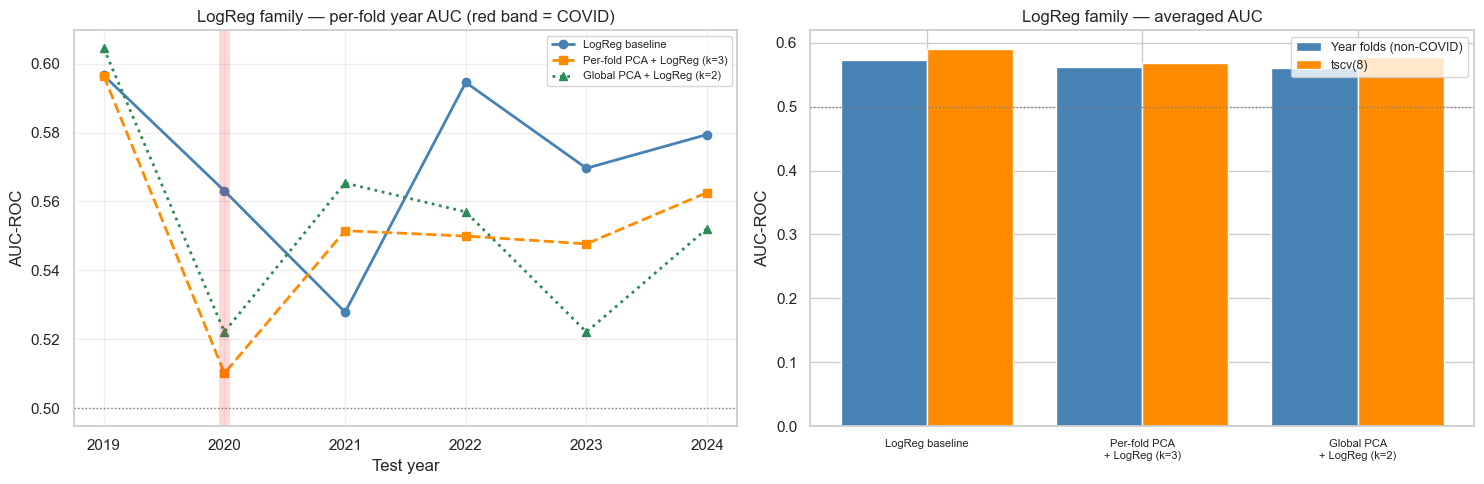

                    Variant  Year AUC (nc)  tscv(8) AUC
            LogReg baseline         0.5736       0.5899
Per-fold PCA + LogReg (k=3)         0.5616       0.5678
  Global PCA + LogReg (k=2)         0.5602       0.5777

Best LogReg variant by non-COVID year AUC: LogReg baseline


In [22]:
# LogReg family — baseline vs per-fold PCA vs global PCA.
lr_family = [
    ('LogReg baseline',
     lr_year['aucs'],
     lr_tscv['aucs'],
     'steelblue', 'o', '-'),
    (f'Per-fold PCA + LogReg (k={best_k_year})',
     pca_lr_detail_year['aucs'],
     pca_tscv_sweep[best_k_tscv]['fold_aucs'],
     'darkorange', 's', '--'),
    (f'Global PCA + LogReg (k={best_kg_year})',
     gpca_year_sweep[best_kg_year]['fold_aucs'],
     gpca_tscv_sweep[best_kg_tscv]['fold_aucs'],
     'seagreen', '^', ':'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for name, yr_a, _, c, mk, ls in lr_family:
    ax.plot(yr_test_years, yr_a, marker=mk, ls=ls, color=c, lw=2, label=name)
ax.axvline(2020, color='red', alpha=0.15, lw=8)
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set(xlabel='Test year', ylabel='AUC-ROC',
       title='LogReg family — per-fold year AUC (red band = COVID)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
names  = [v[0] for v in lr_family]
xs     = np.arange(len(names))
yr_nc  = [non_covid_mean(v[1], yr_test_years) for v in lr_family]
tc_av  = [float(np.mean(v[2])) for v in lr_family]
ax.bar(xs - 0.2, yr_nc, width=0.4, color='steelblue',  label='Year folds (non-COVID)')
ax.bar(xs + 0.2, tc_av, width=0.4, color='darkorange', label=f'tscv({best_n_splits_lr})')
ax.set_xticks(xs)
ax.set_xticklabels([n.replace(' + ', '\n+ ') for n in names], fontsize=8)
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set(ylabel='AUC-ROC', title='LogReg family — averaged AUC')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

lr_cmp = pd.DataFrame([
    {'Variant': n,
     'Year AUC (nc)': round(non_covid_mean(y, yr_test_years), 4),
     f'tscv({best_n_splits_lr}) AUC': round(float(np.mean(t)), 4)}
    for n, y, t, _, _, _ in lr_family
])
print(lr_cmp.to_string(index=False))
winner_lr = lr_cmp.iloc[lr_cmp['Year AUC (nc)'].idxmax()]['Variant']
print(f'\nBest LogReg variant by non-COVID year AUC: {winner_lr}')

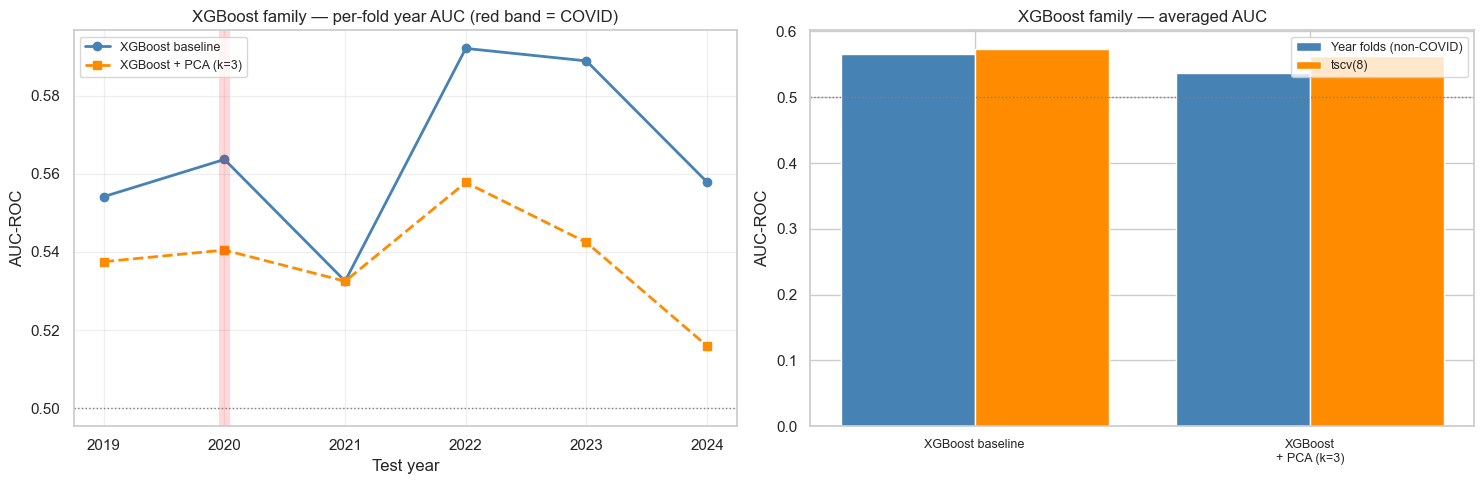

            Variant  Year AUC (nc)  tscv(8) AUC
   XGBoost baseline         0.5651       0.5729
XGBoost + PCA (k=3)         0.5372       0.5621

Best XGBoost variant by non-COVID year AUC: XGBoost baseline


In [23]:
# XGBoost family — baseline vs per-fold PCA.
xgb_family = [
    ('XGBoost baseline',
     xgb_plain_year['aucs'],
     xgb_plain_tscv['aucs'],
     'steelblue', 'o', '-'),
    (f'XGBoost + PCA (k={best_k_year})',
     xgb_pca_year['aucs'],
     xgb_pca_tscv['aucs'],
     'darkorange', 's', '--'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for name, yr_a, _, c, mk, ls in xgb_family:
    ax.plot(yr_test_years, yr_a, marker=mk, ls=ls, color=c, lw=2, label=name)
ax.axvline(2020, color='red', alpha=0.15, lw=8)
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set(xlabel='Test year', ylabel='AUC-ROC',
       title='XGBoost family — per-fold year AUC (red band = COVID)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
names = [v[0] for v in xgb_family]
xs    = np.arange(len(names))
yr_nc = [non_covid_mean(v[1], yr_test_years) for v in xgb_family]
tc_av = [float(np.mean(v[2])) for v in xgb_family]
ax.bar(xs - 0.2, yr_nc, width=0.4, color='steelblue',  label='Year folds (non-COVID)')
ax.bar(xs + 0.2, tc_av, width=0.4, color='darkorange', label=f'tscv({best_n_splits_xgb})')
ax.set_xticks(xs)
ax.set_xticklabels([n.replace(' + ', '\n+ ') for n in names], fontsize=9)
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set(ylabel='AUC-ROC', title='XGBoost family — averaged AUC')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

xgb_cmp = pd.DataFrame([
    {'Variant': n,
     'Year AUC (nc)': round(non_covid_mean(y, yr_test_years), 4),
     f'tscv({best_n_splits_xgb}) AUC': round(float(np.mean(t)), 4)}
    for n, y, t, _, _, _ in xgb_family
])
print(xgb_cmp.to_string(index=False))
winner_xgb = xgb_cmp.iloc[xgb_cmp['Year AUC (nc)'].idxmax()]['Variant']
print(f'\nBest XGBoost variant by non-COVID year AUC: {winner_xgb}')